To detect more complex and hidden linear dependencies, we added a neural network to the comparison. The motivation for using a deep learning architecture was its generality to form its own internal representations of features, and this would be promising for our dataset, which combines weather indicators, time lags, and text vectors. And unlike decision trees, which simply divide the space, it is able to find obvious combinations of these factors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score,
                             roc_auc_score, f1_score, matthews_corrcoef, balanced_accuracy_score)
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_parquet('data_for_ML-tgShifted.parquet')
df = df.sort_values('datetime').reset_index(drop=True)

float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].astype('float32')
int_cols = df.select_dtypes(include='int64').columns
df[int_cols] = df[int_cols].astype('int32')

print(f"Shape: {df.shape}")
print( f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MG")

Shape: (808940, 231)
Memory: 758.7 MG


In [3]:
for lag in [24, 48, 72, 168]:
    df[f'alarms_lag_{lag}h'] = (
        df.groupby('region_id')['alarms_last_24h'].shift(lag)
    )

df['alarms_rolling_24h_mean'] = (
    df.groupby('region_id')['alarms_last_24h']
    .transform(lambda x: x.shift(24).rolling(24).mean())
)

df = df.dropna().reset_index(drop=True)

drop_cols = ['datetime', 'alarm', 'city_address', 'city_latitude',
             'city_longitude', 'region', 'season',
             'regions_in_alarm_now', 'alarms_last_24h']

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].select_dtypes(include=[np.number])
y = df['alarm']

split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Train: {X_train.shape}: {df['datetime'].iloc[0]} - {df['datetime'].iloc[split_idx]}")
print(f"Test:  {X_test.shape}: {df['datetime'].iloc[split_idx]} - {df['datetime'].iloc[-1]}")

Train: (644060, 227): 2022-03-03 00:00:00 - 2025-05-16 02:00:00
Test:  (161016, 227): 2025-05-16 02:00:00 - 2026-03-16 23:00:00


In [4]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [5]:
for layers in [(128, 64), (256, 128), (256, 128, 64)]:
    model = MLPClassifier(
        hidden_layer_sizes=layers, max_iter=50,
        early_stopping=True, validation_fraction=0.1,
        random_state=42
    )
    model.fit(X_train_s, y_train)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    print(f"layers={layers} and ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

layers=(128, 64) and ROC-AUC: 0.7874
layers=(256, 128) and ROC-AUC: 0.8032
layers=(256, 128, 64) and ROC-AUC: 0.8247


In [6]:
model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

model.fit(X_train_s, y_train)
y_prob = model.predict_proba(X_test_s)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

ROC-AUC: 0.8247


In [8]:
y_prob = model.predict_proba(X_test_s)[:, 1]

y_pred_03 = (y_prob >= 0.3).astype(int)

print(classification_report(y_test, y_pred_03, target_names=['No Alarm', 'Alarm']))
print(f"Accuracy: {accuracy_score(y_test, y_pred_03):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}") 
print(f"F1:       {f1_score(y_test, y_pred_03):.4f}")
print(f"MCC:      {matthews_corrcoef(y_test, y_pred_03):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_03):.4f}")

              precision    recall  f1-score   support

    No Alarm       0.88      0.78      0.83    114666
       Alarm       0.57      0.73      0.64     46350

    accuracy                           0.77    161016
   macro avg       0.73      0.76      0.73    161016
weighted avg       0.79      0.77      0.77    161016

Accuracy: 0.7655
ROC-AUC:  0.8247
F1:       0.6427
MCC:      0.4800
Balanced Accuracy: 0.7557


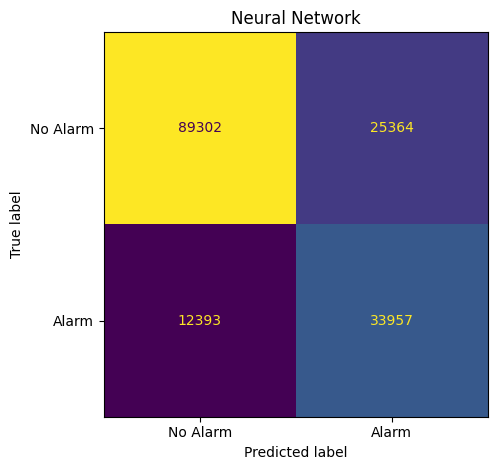

In [12]:
cm = confusion_matrix(y_test, y_pred_03)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Alarm', 'Alarm'])
disp.plot(colorbar=False, values_format='d')
plt.title('Neural Network')
plt.tight_layout()
plt.show()

True Negatives (TN) — 89,302
True Positives (TP) — 33,957
False Negatives (FN) — 12,393
False Positives (FP) — 25,364

Recall ≈ 73.3%
This is significantly lower than that of trees. The neural network sees only 3 out of 4 alarms, which is a serious drawback for a security system.

Precision ≈ 57.2%
This is the highest accuracy of all your models. If the neural network says "there will be an alarm", the probability that it will actually happen is higher than in XGBoost.

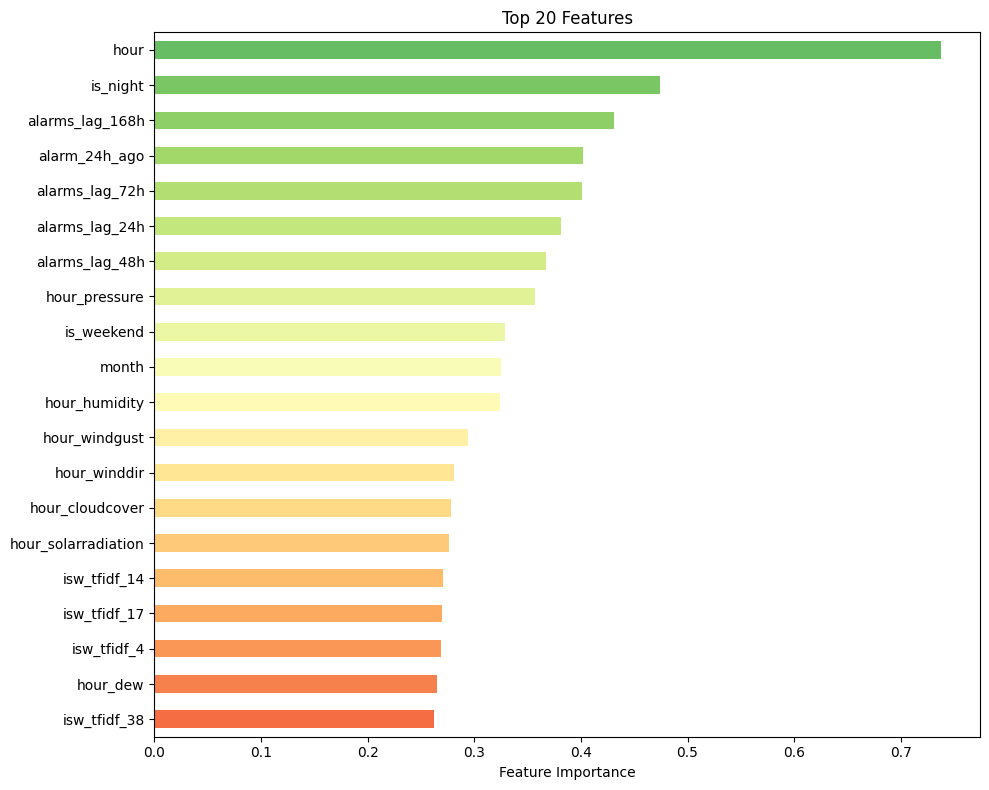

In [13]:
weights = np.abs(model.coefs_[0]).mean(axis=1)
feat_imp = pd.Series(weights, index=X_train.columns)
top20 = feat_imp.nlargest(20)

plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 20))
top20.sort_values().plot(kind='barh', color=colors)
plt.title('Top 20 Features')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

In [14]:
with open('6__mlp__v1.pkl', 'wb') as f:
    pickle.dump(model, f)